In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# Inline plotting configuration
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load the core dataset
df = pd.read_csv('insurance.csv')

print("="*60)
print("1. DATASET OVERVIEW & TARGET PROFILE")
print("="*60)
print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns\n")
display(df.head())

1. DATASET OVERVIEW & TARGET PROFILE
Dataset Dimensions: 100 rows × 8 columns



,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


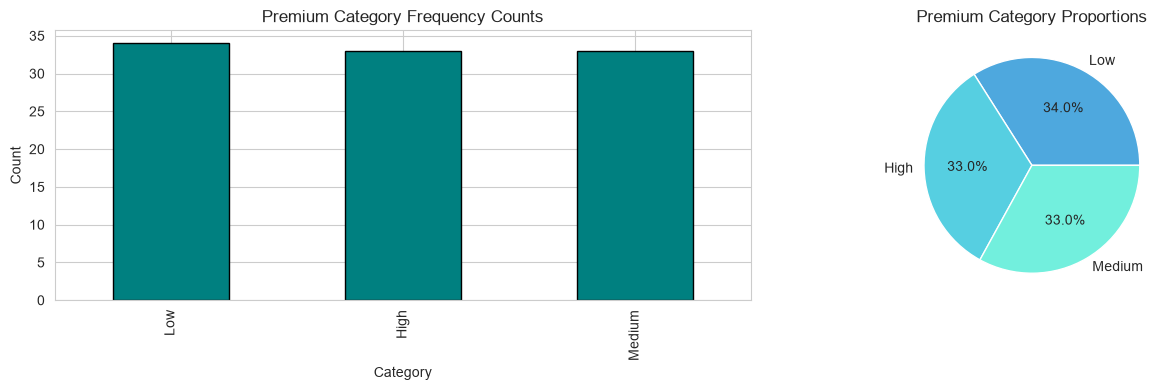

In [3]:
# Target Category Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['insurance_premium_category'].value_counts().plot(kind='bar', ax=ax[0], color='teal', edgecolor='black')
ax[0].set_title('Premium Category Frequency Counts')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Count')

df['insurance_premium_category'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#4ea8de', '#56cfe1', '#72efdd'])
ax[1].set_title('Premium Category Proportions')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [5]:
df_feat = df.copy()

# Feature 1: BMI Calculation
df_feat["bmi"] = df_feat["weight"] / (df_feat["height"] ** 2)

In [6]:
# Feature 2: Age Categorization
def age_group(age):
    if age < 25: return "young"
    elif age < 45: return "adult"
    elif age < 60: return "middle_aged"
    return "senior"
df_feat["age_group"] = df_feat["age"].apply(age_group)

In [7]:
# Feature 3: Complex Lifestyle Risk Metrics
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30: return "high"
    elif row["smoker"] or row["bmi"] > 27: return "medium"
    return "low"
df_feat["lifestyle_risk"] = df_feat.apply(lifestyle_risk, axis=1)

In [8]:
# Feature 4: Geographic Segmentation
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

In [9]:
def city_tier(city):
    if city in tier_1_cities: return 1
    elif city in tier_2_cities: return 2
    return 3
df_feat["city_tier"] = df_feat["city"].apply(city_tier)

In [10]:
# Isolate independent features and target arrays
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]

print("✓ Engineered Features Parsed Successfully.")
display(X.head(5))

✓ Engineered Features Parsed Successfully.


,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,medium,2,2.92,retired
1,30.189017,adult,medium,1,34.28,freelancer
2,21.118382,adult,low,2,36.64,freelancer
3,45.535900,young,high,1,3.34,student
4,24.296875,senior,medium,2,3.94,retired


In [11]:
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [13]:
# Initialize the pipeline with explicit max_depth and min_samples_leaf values to combat overfitting
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(max_depth=5, min_samples_leaf=3, random_state=42))
])

In [14]:
# Reproduce your exact 80/20 train-test split criteria
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [15]:
# Fit pipeline
pipeline.fit(X_train, y_train)
print(f"✓ Pipeline fitted on {X_train.shape[0]} training observations.")

✓ Pipeline fitted on 80 training observations.


In [16]:
# Extract predictions
y_pred = pipeline.predict(X_test)
y_pred_train = pipeline.predict(X_train)

In [17]:
# Calculate generalization metric scores
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

In [18]:
print(f"Training Baseline Accuracy : {train_acc*100:.2f}%")
print(f"Validation Test Accuracy   : {test_acc*100:.2f}%")
print(f"Realized Overfitting Gap   : {(train_acc - test_acc)*100:.2f}%\n")

print("Classification Metrics Matrix:")
print(classification_report(y_test, y_pred))

Training Baseline Accuracy : 86.25%
Validation Test Accuracy   : 75.00%
Realized Overfitting Gap   : 11.25%

Classification Metrics Matrix:
              precision    recall  f1-score   support

        High       0.83      0.71      0.77         7
         Low       0.75      0.75      0.75         4
      Medium       0.70      0.78      0.74         9

    accuracy                           0.75        20
   macro avg       0.76      0.75      0.75        20
weighted avg       0.76      0.75      0.75        20



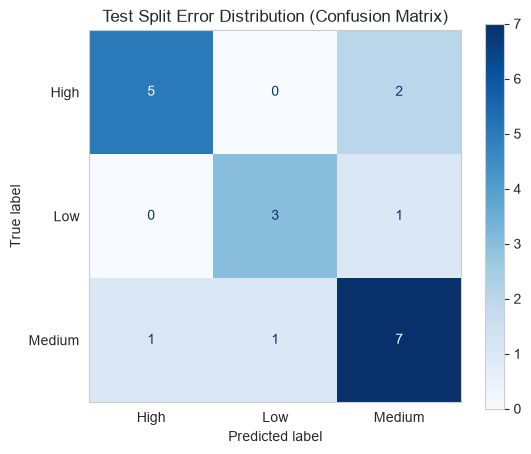

In [19]:
# Render Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.grid(False)
plt.title('Test Split Error Distribution (Confusion Matrix)')
plt.show()

In [20]:
# Save out finalized stable estimator architecture
pickle_model_path = "model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(pipeline, f)

print(f"✓ Production pipeline payload successfully wrapped and saved as: '{pickle_model_path}'")

✓ Production pipeline payload successfully wrapped and saved as: 'model.pkl'
